# sliceheads — Full Pipeline

This notebook walks through the complete sliceheads workflow:

1. Validate an HDF5 embeddings file
2. Load train / val / test splits
3. Run HPO + benchmark for a selection of heads
4. Evaluate on the held-out test set
5. Compute leave-one-out slice importance
6. Persist all results to `results/`

The cells below use a **compact config** (two heads, small grids) so the benchmark finishes in a minute or two.  
To run the full 10-head benchmark instead, execute `python run_experiment.py` from the repository root.

---
**Dataset**: `dataset_normal.h5` — 1 063 CT volumes, DINOv2-B embeddings [N, 768], binary label, pre-split into train / val / test.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import h5py

from sliceheads.store import EmbedStore, validate_h5
from sliceheads.hpo import run_benchmark
from sliceheads.explain import compute_importance_dataset
from sliceheads.results import save_results

H5_PATH = '../dataset_normal.h5'
RESULTS_DIR = '../results_demo'

print('sliceheads pipeline — ready')

sliceheads pipeline — ready


## Step 1 — Validate the HDF5 file

`validate_h5` checks:
- Every sample has `embeddings`, `label`, and `split`.
- Labels are exactly `{0, 1}` (binary-only invariant).
- Embedding dimensions are consistent across samples.
- No patient-ID leakage across splits (where `patient_id` is available).
- `important_slices` length matches N when present.

In [2]:
validate_h5(H5_PATH)
print('Validation passed ✓')

# Inspect file-level metadata
with h5py.File(H5_PATH, 'r') as f:
    sample_keys = list(f.keys())
    root_attrs = dict(f.attrs)

print(f'Total samples : {len(sample_keys)}')
print(f'Root attributes: {[k for k in root_attrs]}')
if 'mean_embedding' in root_attrs:
    me = np.array(root_attrs['mean_embedding'])
    print(f'mean_embedding shape: {me.shape}')

Validation passed ✓
Total samples : 1063
Root attributes: ['mean_embedding']
mean_embedding shape: (768,)


## Step 2 — Load embeddings via EmbedStore

`EmbedStore` is the read/write wrapper around the HDF5 file.  
`load_split` returns a **list of variable-length** arrays `[N_i, D]` — each sample has its own slice count.

In [3]:
store = EmbedStore(H5_PATH)

# Ensure mean_embedding is available (required for LOO importance)
mean_embedding = store.mean_embedding()
if mean_embedding is None:
    print('Computing mean_embedding from train split …')
    mean_embedding = store.compute_and_write_mean_embedding()
print(f'mean_embedding: {mean_embedding.shape}')

emb_train, y_train, ids_train = store.load_split('train')
emb_val,   y_val,   ids_val   = store.load_split('val')
emb_test,  y_test,  ids_test  = store.load_split('test')

print(f'\nSplit sizes  : train={len(emb_train)}  val={len(emb_val)}  test={len(emb_test)}')
print(f'Label balance: 0={int((y_test==0).sum())}  1={int((y_test==1).sum())}  (test set)')

slice_counts = [e.shape[0] for e in emb_train]
print(f'Slice count  : min={min(slice_counts)}  mean={np.mean(slice_counts):.1f}  max={max(slice_counts)}')

mean_embedding: (768,)



Split sizes  : train=637  val=211  test=215
Label balance: 0=52  1=163  (test set)
Slice count  : min=31  mean=41.9  max=67


## Step 3 — Run HPO + benchmark

`run_benchmark` iterates over every **enabled** head in the config, runs grid/random/bayesian HPO on the val split, picks the best configuration, and evaluates it on the test split.

We use a compact config here (MeanPool + GeM, small grids) so the notebook runs fast. Replace `DEMO_CONFIG` with the full `experiment.yaml` content to replicate the paper results.

In [ ]:
DEMO_CONFIG = {
    'search_strategy': 'grid',
    'training': {
        'device': 'cpu',
        'random_seed': 42,   # <- change this to use a different init/split-shuffle seed
        'selection_metric': 'roc_auc',
    },
    'heads': {
        'MeanPoolClassifier': {
            'enabled': True,
            'hyperparameters': {
                'C': [0.1, 1.0, 10.0],
                'class_weight': ['balanced'],
            },
        },
        'GeMPoolClassifier': {
            'enabled': True,
            'hyperparameters': {
                'p': [2.0, 3.0],
                'C': [0.1, 1.0],
                'class_weight': ['balanced'],
            },
        },
    },
}

print('Running HPO + benchmark …')
bench = run_benchmark(
    DEMO_CONFIG,
    emb_train, y_train,
    emb_val,   y_val,
    emb_test,  y_test,
    ids_test,
)
print('Done.')

## Step 4 — Inspect HPO results and test-set metrics

In [5]:
# Best hyperparameters per head
print('=== Best hyperparameters (selected on val ROC-AUC) ===')
for head_name, params in bench['hyperparameters_per_head'].items():
    params_str = '  '.join(f'{k}={v}' for k, v in params.items())
    print(f'  {head_name:<28s} {params_str}')

# HPO grid detail
print('\n=== HPO grid (all combinations, sorted by val ROC-AUC) ===')
for head_name, all_results in bench['hpo_detail_per_head'].items():
    print(f'\n  {head_name}')
    for r in sorted(all_results, key=lambda x: -(x['score'] or -999)):
        score = r['score']
        ps = '  '.join(f'{k}={v}' for k, v in r['params'].items())
        marker = ' <-- best' if r['params'] == bench['hyperparameters_per_head'][head_name] else ''
        print(f'    val_roc_auc={score:.4f}  {ps}{marker}')

=== Best hyperparameters (selected on val ROC-AUC) ===
  MeanPoolClassifier           C=1.0  class_weight=balanced
  GeMPoolClassifier            p=2.0  C=1.0  class_weight=balanced

=== HPO grid (all combinations, sorted by val ROC-AUC) ===

  MeanPoolClassifier
    val_roc_auc=0.8975  C=1.0  class_weight=balanced <-- best
    val_roc_auc=0.8882  C=0.1  class_weight=balanced
    val_roc_auc=0.8752  C=10.0  class_weight=balanced

  GeMPoolClassifier
    val_roc_auc=0.9070  p=2.0  C=1.0  class_weight=balanced <-- best
    val_roc_auc=0.9055  p=3.0  C=1.0  class_weight=balanced
    val_roc_auc=0.8903  p=3.0  C=0.1  class_weight=balanced
    val_roc_auc=0.8891  p=2.0  C=0.1  class_weight=balanced


In [6]:
# Test-set metrics as a DataFrame
rows = []
for head_name, m in bench['metrics_per_head'].items():
    rows.append({
        'Head': head_name,
        'ROC-AUC': f"{m['roc_auc']:.3f}",
        '95% CI': f"[{m['roc_auc_ci_lower']:.3f}, {m['roc_auc_ci_upper']:.3f}]",
        'PR-AUC': f"{m['pr_auc']:.3f}",
        'BAcc': f"{m['balanced_accuracy']:.3f}",
        'Sensitivity': f"{m['sensitivity']:.3f}",
        'Specificity': f"{m['specificity']:.3f}",
        'n_test': m['n_samples'],
    })

df_metrics = pd.DataFrame(rows).set_index('Head')
print('=== Test-set metrics (n=215) ===')
df_metrics

=== Test-set metrics (n=215) ===


,ROC-AUC,95% CI,PR-AUC,BAcc,Sensitivity,Specificity,n_test
Head,,,,,,,
MeanPoolClassifier,0.857,"[0.798, 0.911]",0.946,0.777,0.804,0.750,215
GeMPoolClassifier,0.864,"[0.800, 0.920]",0.941,0.815,0.804,0.827,215


## Step 5 — Leave-one-out slice importance

For every test sample and every head, sliceheads replaces each slice's embedding with the dataset mean embedding and records how much the positive-class probability changes.  
The resulting `importance` vector is non-negative and sums to 1, making it comparable across heads.

> **Note**: LOO is O(N) forward passes per sample. For large test sets or large N, prefer a subset or use GPU.

In [7]:
print('Computing LOO slice importance …')
importance_per_head = {}
for head_name, best_head in bench['best_heads_per_head'].items():
    print(f'  {head_name} …')
    imp = compute_importance_dataset(
        best_head,
        emb_test,
        ids_test,
        mean_embedding,
    )
    importance_per_head[head_name] = imp

# Peek at one sample
sample_id = ids_test[0]
print(f'\nSample: {sample_id}')
for head_name, imp_dict in importance_per_head.items():
    v = imp_dict[sample_id]['importance']
    print(f'  {head_name:<28s} N={len(v)}  max_idx={int(np.argmax(v))}  max_val={v.max():.4f}')

Computing LOO slice importance …
  MeanPoolClassifier …


  GeMPoolClassifier …



Sample: study_0002
  MeanPoolClassifier           N=42  max_idx=26  max_val=0.0757
  GeMPoolClassifier            N=42  max_idx=8  max_val=0.0747


### Visualise importance for one sample

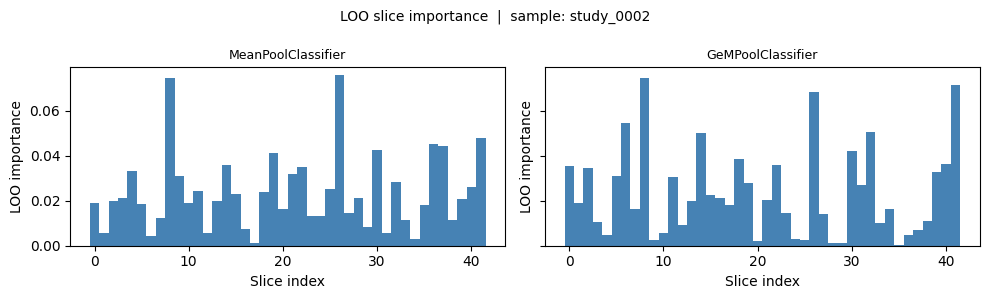

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(importance_per_head), figsize=(5 * len(importance_per_head), 3),
                         sharey=True)
if len(importance_per_head) == 1:
    axes = [axes]

for ax, (head_name, imp_dict) in zip(axes, importance_per_head.items()):
    v = imp_dict[sample_id]['importance']
    ax.bar(range(len(v)), v, color='steelblue', width=1.0)
    ax.set_title(head_name, fontsize=9)
    ax.set_xlabel('Slice index')
    ax.set_ylabel('LOO importance')

fig.suptitle(f'LOO slice importance  |  sample: {sample_id}', fontsize=10)
plt.tight_layout()
plt.show()

## Step 6 — Save results

`save_results` writes the canonical `results/` directory:

| File | Contents |
|---|---|
| `metrics.csv` | Test-set metrics for every head |
| `test_predictions.csv` | Per-sample predictions (prob_class_0, prob_class_1, …) |
| `hyperparameters.json` | Best HPO params per head |
| `importance.h5` | LOO importance arrays keyed by head and sample |
| `config_used.yaml` | Experiment config snapshot |
| `run_metadata.json` | Software / hardware environment |

In [9]:
# Collect patient_id metadata from the HDF5 file
sample_meta = {}
with h5py.File(H5_PATH, 'r') as f:
    for sid in ids_test:
        sample_meta[sid] = {'patient_id': str(f[sid].attrs.get('patient_id', ''))}

save_results(
    RESULTS_DIR,
    metrics_per_head=bench['metrics_per_head'],
    predictions_per_head=bench['predictions_per_head'],
    hyperparameters_per_head=bench['hyperparameters_per_head'],
    importance_per_head=importance_per_head,
    config=DEMO_CONFIG,
    sample_metadata=sample_meta,
)

print(f'Results saved to {RESULTS_DIR}/')
import os
for f in sorted(os.listdir(RESULTS_DIR)):
    size = os.path.getsize(os.path.join(RESULTS_DIR, f))
    print(f'  {f:<25s} {size:>8,} bytes')

Results saved to ../results_demo/
  config_used.yaml               406 bytes
  hyperparameters.json           167 bytes
  importance.h5              877,960 bytes
  metrics.csv                    814 bytes
  run_metadata.json              342 bytes
  test_predictions.csv        31,489 bytes


## Summary

You have run the full sliceheads pipeline:

```
HDF5 file
  └─ validate_h5()          # schema + binary invariant check
  └─ EmbedStore.load_split  # train / val / test lists of [N_i, 768]
      └─ run_benchmark()    # HPO + test eval for each enabled head
          └─ compute_importance_dataset()  # LOO per sample
              └─ save_results()            # results/ directory
```

**Next steps**:
- See `02_add_a_head.ipynb` to add your own classification head.
- See `03_explainability.ipynb` to explore LOO importance and native attention in depth.
- Run the full benchmark: `python run_experiment.py --config experiment.yaml`